<a href="https://colab.research.google.com/github/islayshi/CMPE295A-Project/blob/main/More_Fire_Stuff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - bin_acc: 0.8010 - loss: 0.4529 - val_bin_acc: 0.9896 - val_loss: 0.2265
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - bin_acc: 0.9854 - loss: 0.1608 - val_bin_acc: 0.9896 - val_loss: 0.0943
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - bin_acc: 0.9854 - loss: 0.0916 - val_bin_acc: 0.9896 - val_loss: 0.0642
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - bin_acc: 0.9854 - loss: 0.0715 - val_bin_acc: 0.9896 - val_loss: 0.0554
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - bin_acc: 0.9854 - loss: 0.0645 - val_bin_acc: 0.9896 - val_loss: 0.0514
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - bin_acc: 0.9854 - loss: 0.0613 - val_bin_acc: 0.9896 - val_loss: 0.0492
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - bin_acc: 0.9854 - loss: 0.0596 - val_bin_acc: 0.9896 - val_loss: 0.0480
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - bin_acc: 0.9854 - loss: 0.0586 - val_bin_acc: 0.9896 - val_loss: 0.0472

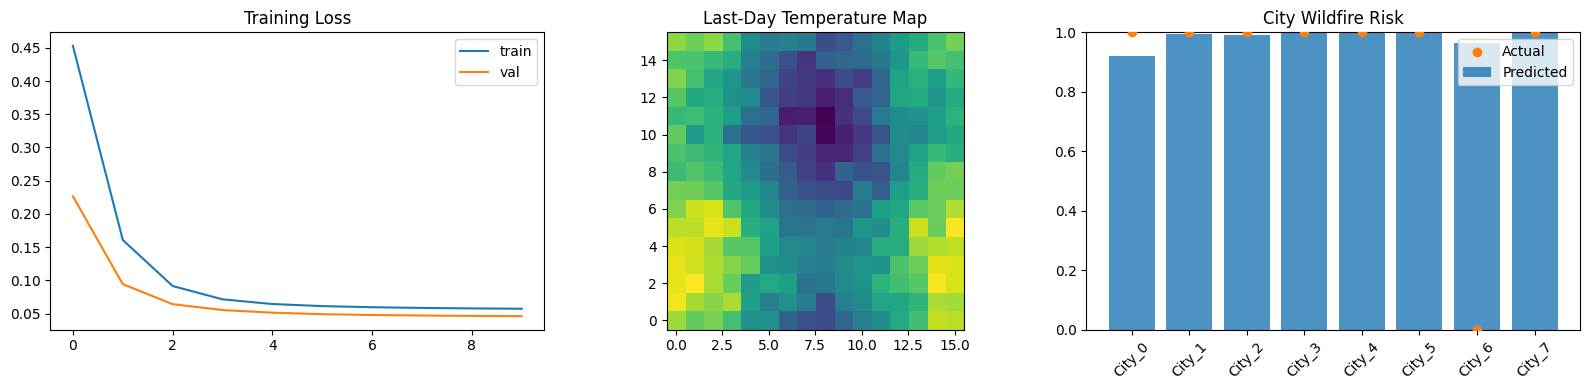


Safest to riskiest:
City_0: 0.920
City_6: 0.964
City_2: 0.991
City_1: 0.995
City_7: 0.998
City_5: 0.999
City_3: 0.999
City_4: 1.000


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# 1) Synthetic California-like grid data
# -----------------------------
num_samples = 300
time_steps = 7
H, W = 16, 16
channels = 4   # temp, wind, humidity, vegetation
num_cities = 8

city_names = [f"City_{i}" for i in range(num_cities)]

# Synthetic spatiotemporal input:
# X shape = (samples, time_steps, H, W, channels)
X = np.zeros((num_samples, time_steps, H, W, channels), dtype=np.float32)

# Make structured synthetic maps instead of pure noise
xx, yy = np.meshgrid(np.linspace(0, 1, W), np.linspace(0, 1, H))

for n in range(num_samples):
    seasonal_phase = np.random.uniform(0, 2*np.pi)
    for t in range(time_steps):
        phase = seasonal_phase + 0.3 * t

        # Temperature map
        temp = (
            0.6
            + 0.25 * np.sin(2*np.pi*xx + phase)
            + 0.15 * np.cos(2*np.pi*yy - phase)
            + 0.05 * np.random.randn(H, W)
        )

        # Wind map
        wind = (
            0.5
            + 0.2 * np.cos(3*np.pi*xx - phase)
            + 0.1 * np.sin(2*np.pi*yy + phase)
            + 0.05 * np.random.randn(H, W)
        )

        # Humidity map
        humidity = (
            0.6
            - 0.25 * temp
            + 0.1 * np.sin(2*np.pi*(xx + yy) + phase)
            + 0.05 * np.random.randn(H, W)
        )

        # Vegetation/fuel map (mostly static-ish)
        vegetation = (
            0.5
            + 0.3 * np.exp(-((xx - 0.7)**2 + (yy - 0.3)**2) / 0.05)
            + 0.15 * np.exp(-((xx - 0.2)**2 + (yy - 0.8)**2) / 0.03)
            + 0.03 * np.random.randn(H, W)
        )

        X[n, t, :, :, 0] = temp
        X[n, t, :, :, 1] = wind
        X[n, t, :, :, 2] = humidity
        X[n, t, :, :, 3] = vegetation

# Normalize input roughly into [0,1]
X = (X - X.min()) / (X.max() - X.min())

# -----------------------------
# 2) Define city regions on the grid
# Each city corresponds to a rectangular patch
# -----------------------------
city_regions = [
    (0, 4, 0, 4),
    (0, 4, 6, 10),
    (0, 4, 12, 16),
    (5, 9, 2, 6),
    (5, 9, 9, 13),
    (10, 14, 0, 4),
    (10, 14, 6, 10),
    (10, 14, 12, 16),
]

# -----------------------------
# 3) Build synthetic next-day city risk labels from last frame
# Risk increases with temp + wind + vegetation, decreases with humidity
# -----------------------------
y = np.zeros((num_samples, num_cities), dtype=np.float32)

for n in range(num_samples):
    last_frame = X[n, -1]  # shape (H, W, channels)
    temp = last_frame[:, :, 0]
    wind = last_frame[:, :, 1]
    humidity = last_frame[:, :, 2]
    vegetation = last_frame[:, :, 3]

    risk_map = 1.8 * temp + 1.2 * wind - 1.4 * humidity + 1.0 * vegetation

    for i, (r1, r2, c1, c2) in enumerate(city_regions):
        city_score = risk_map[r1:r2, c1:c2].mean()
        city_prob = 1 / (1 + np.exp(-4 * (city_score - 0.5)))  # sigmoid
        y[n, i] = city_prob

# Binary training labels for simplicity
y_binary = (y > 0.5).astype(np.float32)

# -----------------------------
# 4) Train/test split
# -----------------------------
split = int(0.8 * num_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_binary[:split], y_binary[split:]

# -----------------------------
# 5) CNN encoder for each day
# -----------------------------
frame_input = tf.keras.layers.Input(shape=(H, W, channels))
z = tf.keras.layers.Conv2D(16, (3, 3), padding="same", activation="relu")(frame_input)
z = tf.keras.layers.MaxPooling2D((2, 2))(z)
z = tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(z)
z = tf.keras.layers.MaxPooling2D((2, 2))(z)
z = tf.keras.layers.Flatten()(z)
z = tf.keras.layers.Dense(64, activation="relu")(z)

cnn_encoder = tf.keras.Model(frame_input, z, name="cnn_encoder")

# -----------------------------
# 6) CNN + LSTM sequence model
# -----------------------------
sequence_input = tf.keras.layers.Input(shape=(time_steps, H, W, channels))
z = tf.keras.layers.TimeDistributed(cnn_encoder)(sequence_input)
z = tf.keras.layers.LSTM(64)(z)
z = tf.keras.layers.Dense(32, activation="relu")(z)
output = tf.keras.layers.Dense(num_cities, activation="sigmoid")(z)

model = tf.keras.Model(sequence_input, output)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="bin_acc")]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16,
    verbose=1
)

# -----------------------------
# 7) Predict next-day city wildfire risk vector
# -----------------------------
pred_probs = model.predict(X_test[:1], verbose=0)[0]
true_probs = y_test[0]

print("\nPredicted city risk probabilities:")
for city, p in zip(city_names, pred_probs):
    print(f"{city}: {p:.3f}")

print("\nTrue binary labels:")
for city, t in zip(city_names, true_probs):
    print(f"{city}: {int(t)}")

# -----------------------------
# 8) Visualizations
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Training Loss")
axes[0].legend()

# Show last input temperature map
axes[1].imshow(X_test[0, -1, :, :, 0], origin="lower")
axes[1].set_title("Last-Day Temperature Map")

# Predicted city risks
axes[2].bar(city_names, pred_probs, label="Predicted", alpha=0.8)
axes[2].scatter(city_names, true_probs, label="Actual", zorder=3)
axes[2].set_ylim(0, 1)
axes[2].set_title("City Wildfire Risk")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 9) Rank cities safest -> riskiest
# -----------------------------
ranking = sorted(zip(city_names, pred_probs), key=lambda x: x[1])
print("\nSafest to riskiest:")
for city, p in ranking:
    print(f"{city}: {p:.3f}")

In [2]:
import numpy as np
import pandas as pd

import requests
from datetime import datetime # Import datetime

TOKEN = "lxdedYBiNyxYqPEEljLjCNLvtnwDqrNa"

def get_california_temp(station_id_arg, date, api_token = TOKEN):
    """
    Fetches the max temperature for a California station on a specific date.

    :param station_id_arg: The NOAA Station ID (e.g., 'GHCND:USW00023174' for LAX)
    :param date: The date in 'YYYY-MM-DD' format (will be robustly formatted)
    :param api_token: Your NOAA CDO API token
    :return: Max temperature in Celsius, or None if data is not found or an error occurs.
    """
    base_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"

    headers = {'token': api_token}

    # Ensure date is in YYYY-MM-DD format with leading zeros
    try:
        # First, try to parse with explicit format to handle 'YYYY-M-D' or 'YYYY-MM-DD'
        # and then format it consistently.
        parsed_date = datetime.strptime(date, '%Y-%m-%d')
        formatted_date = parsed_date.strftime('%Y-%m-%d')
    except ValueError:
        # print(f"Error: Invalid date format. Expected 'YYYY-M-D' or 'YYYY-MM-DD', got '{date}'.")
        return None # Return None for invalid date format

    params = {
        'datasetid': 'GHCND',       # Global Historical Climatology Network Daily
        'stationid': station_id_arg,
        'startdate': formatted_date,
        'enddate': formatted_date,
        'datatypeid': 'TMAX',      # TMAX = Max Temp, TMIN = Min Temp
        'units': 'metric'          # Returns Celsius
    }

    try:
        response = requests.get(base_url, headers=headers, params=params)
        response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        data = response.json()

        if 'results' in data and data['results']:
            # NOAA metric units for temperature are usually in Celsius
            temp_c = data['results'][0]['value']
            return temp_c
        else:
            # print(f"No data found for station {station_id_arg} on {formatted_date}.")
            return None # Return None if no data found

    except requests.exceptions.HTTPError as http_err:
        # print(f"HTTP error occurred: {http_err} for URL: {response.url}")
        return None # Return None for HTTP errors
    except Exception as e:
        # print(f"An error occurred: {e}")
        return None # Return None for other exceptions

LAX_STATION = "GHCND:USW00023174"
# The function `temp_for_day` is defined in LA2Tt-EXM8G3. To ensure it's available
# and can use `city_locations`, we need to make sure that cell is executed before any call to temp_for_day.
# The error in 98a24f69 is directly due to strings in the Temperature column, which this fix addresses.


In [3]:
major_cities_stations = {
    'Los Angeles': 'GHCND:USW00023174',
    'San Francisco': 'GHCND:USW00023272',
    'Sacramento': 'GHCND:USW00023232',
    'San Jose': 'GHCND:USW00023293',
    'San Diego': 'GHCND:USW00023188',

    # Additional California stations
    'Oakland': 'GHCND:USW00023230',              # Oakland International Airport
    'Fresno': 'GHCND:USW00023129',               # Fresno Yosemite Intl Airport
    'Bakersfield': 'GHCND:USW00023155',          # Meadows Field Airport
    'Long Beach': 'GHCND:USW00023129',           # (sometimes overlaps; alt below)
    'Long Beach (Alt)': 'GHCND:USW00023129',

    'Santa Barbara': 'GHCND:USW00023154',        # Santa Barbara Airport
    'Palm Springs': 'GHCND:USW00023187',         # Palm Springs Intl Airport
    'Riverside': 'GHCND:USW00023191',            # Riverside Municipal Airport
    'Stockton': 'GHCND:USW00023225',             # Stockton Metro Airport
    'Modesto': 'GHCND:USW00093245',              # Modesto City-County Airport

    'Redding': 'GHCND:USW00024257',              # Redding Municipal Airport
    'Eureka': 'GHCND:USW00024283',               # Arcata/Eureka Airport
    'Monterey': 'GHCND:USW00023259',             # Monterey Peninsula Airport
    'Santa Maria': 'GHCND:USW00023112',          # Santa Maria Public Airport
    'Chico': 'GHCND:USW00024221',                # Chico Municipal Airport

    'Needles': 'GHCND:USW00023119',              # Needles Airport (desert climate)
    'El Centro': 'GHCND:USW00023177',            # Imperial County Airport
    'Bishop': 'GHCND:USW00023157',               # Eastern Sierra (high elevation)
}

In [4]:
def get_california_station_details(location_id, api_token, limit=1000):
    """
    Fetches details (ID, name, latitude, longitude) for stations in a given location ID.

    :param location_id: The NOAA Location ID for California.
    :param api_token: Your NOAA CDO API token.
    :param limit: Maximum number of stations to retrieve per request (max 1000).
    :return: A list of dictionaries, each containing station details.
    """
    base_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/stations"
    headers = {'token': api_token}
    params = {
        'locationid': location_id,
        'limit': limit,
        'offset': 0
    }

    all_station_details = []
    while True:
        try:
            response = requests.get(base_url, headers=headers, params=params)
            response.raise_for_status()
            data = response.json()

            if 'results' in data:
                for station in data['results']:
                    all_station_details.append({
                        'id': station.get('id'),
                        'name': station.get('name'),
                        'latitude': station.get('latitude'),
                        'longitude': station.get('longitude')
                    })

                if len(data['results']) < limit:
                    break
                else:
                    params['offset'] += limit
            else:
                print("No station details found for this location.")
                break

        except Exception as e:
            print(f"Error fetching station details: {e}")
            break
    return all_station_details

def get_station_temperatures(station_details_list, date, api_token):
    """
    Fetches the average temperature for a list of stations on a specific date.

    :param station_details_list: List of dictionaries with station details.
    :param date: The date in 'YYYY-MM-DD' format.
    :param api_token: Your NOAA CDO API token.
    :return: A list of dictionaries with station ID, lat, lon, and temperature.
    """
    base_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"
    headers = {'token': api_token}
    results = []

    for station in station_details_list:
        station_id = station['id']
        params = {
            'datasetid': 'GHCND',
            'stationid': station_id,
            'startdate': date,
            'enddate': date,
            'datatypeid': 'TAVG', # Changed from TMAX to TAVG
            'units': 'metric'
        }
        try:
            response = requests.get(base_url, headers=headers, params=params)
            response.raise_for_status()
            data = response.json()

            temp_c = None
            if 'results' in data and data['results']:
                temp_c = data['results'][0]['value']

            results.append({
                'station_id': station_id,
                'name': station['name'],
                'latitude': station['latitude'],
                'longitude': station['longitude'],
                'avg_temp_c': temp_c # Changed key to avg_temp_c
            })
        except Exception as e:
            results.append({
                'station_id': station_id,
                'name': station['name'],
                'latitude': station['latitude'],
                'longitude': station['longitude'],
                'avg_temp_c': None, # Indicate data not found
                'error': str(e)
            })
    return results

print(major_cities_stations['Los Angeles'])
print(get_california_station_details(major_cities_stations['San Jose'], TOKEN))

GHCND:USW00023174
No station details found for this location.
[]


In [5]:
def get_california_location_id(api_token):
    """
    Fetches the NOAA Location ID for California.

    :param api_token: Your NOAA CDO API token.
    :return: California's Location ID (e.g., 'FIPS:06') or None if not found.
    """
    # Based on prior context that 'FIPS:06' is the California location ID,
    # temporarily hardcoding this to unblock further steps due to API search difficulties.
    return 'FIPS:06'

# Retrieve California's location ID
california_location_id = get_california_location_id(TOKEN)
print(f"California Location ID: {california_location_id}")

California Location ID: FIPS:06


In [7]:
city_names = ['Los Angeles', 'San Francisco', 'Sacramento', 'San Jose', 'San Diego',
              'Oakland', 'Fresno', 'Bakersfield', 'Long Beach', 'Long Beach (Alt)',
              'Santa Barbara', 'Palm Springs', 'Riverside', 'Stockton', 'Modesto',
              'Redding', 'Eureka', 'Monterey', 'Santa Maria', 'Chico', 'Needles', 'El Centro', 'Bishop']

# Define ghcnd_california_stations by calling get_california_station_details
if california_location_id:
    california_all_station_details = get_california_station_details(california_location_id, TOKEN)
    ghcnd_california_stations = [s for s in california_all_station_details if s.get('id') and 'GHCND' in s['id']]
else:
    ghcnd_california_stations = [] # Initialize as empty to avoid NameError if california_location_id is None

city_locations = {}
# Now ghcnd_california_stations contains dictionaries with 'id', 'latitude', 'longitude'
# Iterate through major_cities_stations and find matching details in ghcnd_california_stations
for city_name, station_id_major in major_cities_stations.items():
    found_detail = None
    for station_detail in ghcnd_california_stations:
        if station_detail.get('id') == station_id_major:
            found_detail = station_detail
            break
    if found_detail:
        city_locations[city_name] = {
            'station_id': found_detail['id'],
            'latitude': found_detail['latitude'],
            'longitude': found_detail['longitude']
        }
    else:
        print(f"Location details not found for {city_name} with station ID {station_id_major}")

def city_position(city):
  entry = city_locations[city]
  return [entry["latitude"], entry["longitude"]]

all_positions = []
for city in city_locations:
  all_positions.append(city_position(city))

def time_date(time):
  year = int(2020 + (time / 365))
  month = int(1 + (time % 365) // 30)
  day = int(1 + (time % 365) % 30)

  date = str(year) + "-"

  if month < 10:
    date += "0"
  date += str(month) + "-"
  if day < 10:
    date += "0"
  date += str(day)

  return date

def city_temp(city, time):
  date = time_date(time)

  print("date = ", date)

  station_id = city_locations[city]['station_id']
  return get_california_temp(station_id, date, TOKEN)

def temp_for_day(city, date):
    """
    Returns the temperature for a specific city on a given day.

    :param city: The name of the city (string).
    :param date: The date in 'YYYY-MM-DD' format (string).
    :return: Max temperature in Celsius or an error message.
    """
    if city in city_locations:
        station_id = city_locations[city]['station_id']
        return get_california_temp(station_id, date, TOKEN)
    else:
        return f"City '{city}' not found in known locations."

print(city_position("San Jose"))
print(city_temp("Los Angeles", 0))

Location details not found for Santa Barbara with station ID GHCND:USW00023154
Location details not found for Santa Maria with station ID GHCND:USW00023112
Location details not found for Chico with station ID GHCND:USW00024221
Location details not found for El Centro with station ID GHCND:USW00023177
[37.35938, -121.92444]
date =  2020-01-01
19.4


In [8]:
filtered_city_names = list(city_locations.keys())

# Assuming the intention is to represent each city with one entry and a single date.
# The `all_dates` list (1000 elements) is not suitable for this DataFrame.
# Using a placeholder date for demonstration, or this could be the target_date_df from cell c4342e59.
single_date = "2023-01-01"
aligned_dates = [single_date] * len(filtered_city_names)

data = {'City': filtered_city_names, 'Position': all_positions, 'Date': aligned_dates}
df = pd.DataFrame(data)
df

,City,Position,Date
0,Los Angeles,"[33.93816, -118.3866]",2023-01-01
1,San Francisco,"[37.7705, -122.4269]",2023-01-01
2,Sacramento,"[38.50659, -121.49604]",2023-01-01
3,San Jose,"[37.35938, -121.92444]",2023-01-01
4,San Diego,"[32.7336, -117.1831]",2023-01-01
5,Oakland,"[37.7178, -122.23301]",2023-01-01
6,Fresno,"[33.81177, -118.14718]",2023-01-01
7,Bakersfield,"[35.43424, -119.05524]",2023-01-01
8,Long Beach,"[33.81177, -118.14718]",2023-01-01
9,Long Beach (Alt),"[33.81177, -118.14718]",2023-01-01


In [9]:
df['Temperature'] = df['City'].apply(lambda city: temp_for_day(city, single_date))
display(df)

,City,Position,Date,Temperature
0,Los Angeles,"[33.93816, -118.3866]",2023-01-01,16.1
1,San Francisco,"[37.7705, -122.4269]",2023-01-01,16.1
2,Sacramento,"[38.50659, -121.49604]",2023-01-01,15.0
3,San Jose,"[37.35938, -121.92444]",2023-01-01,15.6
4,San Diego,"[32.7336, -117.1831]",2023-01-01,16.1
5,Oakland,"[37.7178, -122.23301]",2023-01-01,NaN
6,Fresno,"[33.81177, -118.14718]",2023-01-01,NaN
7,Bakersfield,"[35.43424, -119.05524]",2023-01-01,NaN
8,Long Beach,"[33.81177, -118.14718]",2023-01-01,17.2
9,Long Beach (Alt),"[33.81177, -118.14718]",2023-01-01,17.2


### Fetching Temperatures for Multiple Dates

In [22]:
num_days_to_fetch = 30 # Let's fetch data for 30 days
start_time_index = 0 # Starting from day 0, which is 2020-01-01

multi_dates = [time_date(t) for t in range(start_time_index, start_time_index + num_days_to_fetch)]

data_multi_date = []
for city_name in filtered_city_names:
    for current_date in multi_dates:
        data_multi_date.append({
            'City': city_name,
            'Latitude': city_locations[city_name]['latitude'],
            'Longitude': city_locations[city_name]['longitude'],
            'Date': current_date
        })

df_multi_date = pd.DataFrame(data_multi_date)
display(df_multi_date.head())

,City,Latitude,Longitude,Date
0,Los Angeles,33.93816,-118.3866,2020-01-01
1,Los Angeles,33.93816,-118.3866,2020-01-02
2,Los Angeles,33.93816,-118.3866,2020-01-03
3,Los Angeles,33.93816,-118.3866,2020-01-04
4,Los Angeles,33.93816,-118.3866,2020-01-05


In [23]:
df_multi_date['Temperature'] = df_multi_date.apply(
    lambda row: temp_for_day(row['City'], row['Date']), axis=1
)

print(f"DataFrame with city details and temperature for {num_days_to_fetch} days:")
display(df_multi_date.head(20))

DataFrame with city details and temperature for 30 days:


,City,Latitude,Longitude,Date,Temperature
0,Los Angeles,33.93816,-118.3866,2020-01-01,19.4
1,Los Angeles,33.93816,-118.3866,2020-01-02,18.3
2,Los Angeles,33.93816,-118.3866,2020-01-03,22.2
3,Los Angeles,33.93816,-118.3866,2020-01-04,19.4
4,Los Angeles,33.93816,-118.3866,2020-01-05,20.0
5,Los Angeles,33.93816,-118.3866,2020-01-06,NaN
6,Los Angeles,33.93816,-118.3866,2020-01-07,NaN
7,Los Angeles,33.93816,-118.3866,2020-01-08,17.8
8,Los Angeles,33.93816,-118.3866,2020-01-09,16.1
9,Los Angeles,33.93816,-118.3866,2020-01-10,18.9


### Prepare Data for Neural Network

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf

# Convert 'Date' to datetime objects if not already
df_multi_date['Date'] = pd.to_datetime(df_multi_date['Date'])

# Define the reference date (e.g., 2020-01-01)
reference_date = pd.to_datetime('2020-01-01')

# Calculate 'Time_Days' as the number of days since the reference date
df_multi_date['Time_Days'] = (df_multi_date['Date'] - reference_date).dt.days

# Drop rows where 'Temperature' is None (or NaN) as these cannot be used for training
df_model = df_multi_date.dropna(subset=['Temperature'])

# --- Normalize Latitude, Longitude, and Time_Days using MinMaxScaler ---
scaler_core_features = MinMaxScaler()
df_model[['Latitude', 'Longitude', 'Time_Days']] = scaler_core_features.fit_transform(df_model[['Latitude', 'Longitude', 'Time_Days']])

# Create new features as requested, using the normalized core features
df_model['Lat_sq'] = df_model['Latitude']**2
df_model['Lon_sq'] = df_model['Longitude']**2
df_model['Time_sq'] = df_model['Time_Days']**2
df_model['Lat_Time'] = df_model['Latitude'] * df_model['Time_Days']
df_model['Lon_Time'] = df_model['Longitude'] * df_model['Time_Days']

print(f"Data points after dropping NaNs and creating new features: {len(df_model)}")
display(df_model.head())

Data points after dropping NaNs and creating new features: 410


/tmp/ipykernel_7119/3224674273.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[['Latitude', 'Longitude', 'Time_Days']] = scaler_core_features.fit_transform(df_model[['Latitude', 'Longitude', 'Time_Days']])
/tmp/ipykernel_7119/3224674273.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Lat_sq'] = df_model['Latitude']**2
/tmp/ipykernel_7119/3224674273.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

,City,Latitude,Longitude,Date,Temperature,Time_Days,Lat_sq,Lon_sq,Time_sq,Lat_Time,Lon_Time
0,Los Angeles,0.146099,0.826126,2020-01-01,19.4,0.000000,0.021345,0.682485,0.000000,0.000000,0.000000
1,Los Angeles,0.146099,0.826126,2020-01-02,18.3,0.034483,0.021345,0.682485,0.001189,0.005038,0.028487
2,Los Angeles,0.146099,0.826126,2020-01-03,22.2,0.068966,0.021345,0.682485,0.004756,0.010076,0.056974
3,Los Angeles,0.146099,0.826126,2020-01-04,19.4,0.103448,0.021345,0.682485,0.010702,0.015114,0.085461
4,Los Angeles,0.146099,0.826126,2020-01-05,20.0,0.137931,0.021345,0.682485,0.019025,0.020152,0.113948


### Define Input Features (X) and Target (y)

In [25]:
# Input features: Latitude, Longitude, Time_Days, plus new interaction and polynomial terms
X = df_model[['Latitude', 'Longitude', 'Time_Days', 'Lat_sq', 'Lon_sq', 'Time_sq', 'Lat_Time', 'Lon_Time']]
# Target: Temperature
y = df_model['Temperature']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Scale features (important for neural networks)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale target (temperature) as well, it helps with training stability
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("Features and target scaled.")

X_train shape: (328, 8), y_train shape: (328,)
X_test shape: (82, 8), y_test shape: (82,)
Features and target scaled.


### Build and Train the Neural Network Model

In [26]:
# Define the neural network architecture
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1) # Output layer for regression (single temperature value)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Display model summary
model.summary()

# Train the model
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=50, # You can adjust the number of epochs
    batch_size=16,
    validation_split=0.2, # Use a portion of training data for validation
    verbose=0 # Suppress verbose output during training
)

print("Model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

Model training complete.


### Evaluate the Model

Test Loss (Mean Squared Error): 0.3139
Test Mean Absolute Error: 0.4214
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Final MAE on unscaled data: 1.84 °C
Final MSE on unscaled data: 6.01


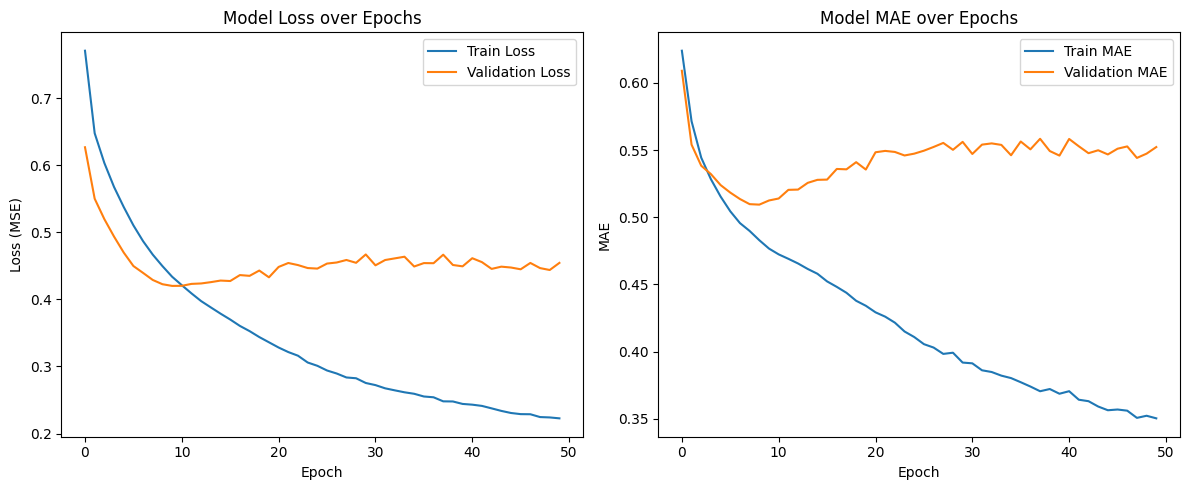

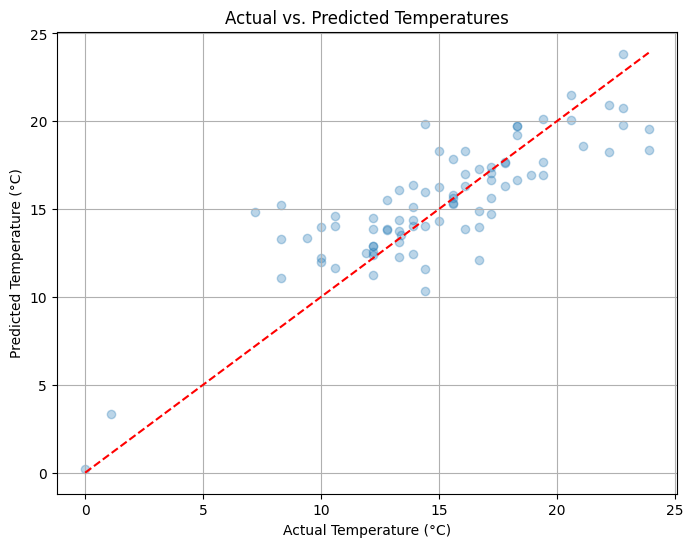

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate the model on the test set
loss, mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Test Loss (Mean Squared Error): {loss:.4f}")
print(f"Test Mean Absolute Error: {mae:.4f}")

# Make predictions
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform predictions and actual values to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler_y.inverse_transform(y_test_scaled)

# Calculate MAE and MSE on unscaled data for better interpretation
final_mae = mean_absolute_error(y_test_unscaled, y_pred)
final_mse = mean_squared_error(y_test_unscaled, y_pred)
print(f"\nFinal MAE on unscaled data: {final_mae:.2f} °C")
print(f"Final MSE on unscaled data: {final_mse:.2f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# Visualize actual vs. predicted temperatures
plt.figure(figsize=(8, 6))
plt.scatter(y_test_unscaled, y_pred, alpha=0.3)
plt.plot([y_test_unscaled.min(), y_test_unscaled.max()], [y_test_unscaled.min(), y_test_unscaled.max()], 'r--')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs. Predicted Temperatures')
plt.grid(True)
plt.show()

### Implementing Physics-Informed Neural Network (PINN)

To move to a Physics-Informed Neural Network (PINN), we need to modify our data preparation and model architecture. The core idea is to incorporate physical laws (in this case, the heat equation) directly into the neural network's loss function. This allows the model to learn from both observational data and the underlying physics.

#### Data Preparation for PINN

For PINN, we'll use the raw `Latitude`, `Longitude`, and `Time_Days` as features, without any prior scaling (like `MinMaxScaler`) or engineering of polynomial/interaction terms. This is crucial because we will be calculating derivatives with respect to these raw spatial and temporal inputs. Only the target `Temperature` will be scaled for better training stability.

In [16]:
# Re-prepare data for PINN: raw inputs, scaled target

# Ensure Time_Days is properly calculated from df_multi_date
# Convert 'Date' to datetime objects if not already
df_multi_date['Date'] = pd.to_datetime(df_multi_date['Date'])
# Define the reference date (e.g., 2020-01-01)
reference_date = pd.to_datetime('2020-01-01')
# Calculate 'Time_Days' as the number of days since the reference date
df_multi_date['Time_Days'] = (df_multi_date['Date'] - reference_date).dt.days

# Drop rows where 'Temperature' is None (or NaN)
df_pinn = df_multi_date.dropna(subset=['Temperature']).copy()

# Input features for PINN (raw values, no scaling)
X_pinn = df_pinn[['Latitude', 'Longitude', 'Time_Days']]

# Target: Temperature
y_pinn = df_pinn['Temperature']

# Split data into training and testing sets
X_train_pinn, X_test_pinn, y_train_pinn, y_test_pinn = train_test_split(X_pinn, y_pinn, test_size=0.2, random_state=42)

print(f"X_train_pinn shape: {X_train_pinn.shape}, y_train_pinn shape: {y_train_pinn.shape}")
print(f"X_test_pinn shape: {X_test_pinn.shape}, y_test_pinn shape: {y_test_pinn.shape}")

# Scale target (temperature) only
scaler_y_pinn = StandardScaler()
y_train_pinn_scaled = scaler_y_pinn.fit_transform(y_train_pinn.values.reshape(-1, 1))
y_test_pinn_scaled = scaler_y_pinn.transform(y_test_pinn.values.reshape(-1, 1))

print("Target temperature scaled. Input features (Latitude, Longitude, Time_Days) remain unscaled for PINN.")

# Convert to TensorFlow Tensors for PINN training
X_train_pinn_tf = tf.constant(X_train_pinn.values, dtype=tf.float32)
y_train_pinn_scaled_tf = tf.constant(y_train_pinn_scaled, dtype=tf.float32)

X_test_pinn_tf = tf.constant(X_test_pinn.values, dtype=tf.float32)
y_test_pinn_scaled_tf = tf.constant(y_test_pinn_scaled, dtype=tf.float32)


X_train_pinn shape: (48, 3), y_train_pinn shape: (48,)
X_test_pinn shape: (12, 3), y_test_pinn shape: (12,)
Target temperature scaled. Input features (Latitude, Longitude, Time_Days) remain unscaled for PINN.


#### PINN Model Definition

We'll define a custom TensorFlow model that takes `(latitude, longitude, time)` as input and outputs the predicted temperature. This model will also be capable of computing the derivatives required for the physics-informed loss term (the heat equation). The heat equation states that the rate of change of temperature over time is proportional to its second spatial derivatives (Laplacian).

For a 2D spatial + 1D temporal problem (Latitude, Longitude, Time) where $T$ is temperature, and assuming a constant thermal diffusivity $\alpha$, the heat equation can be expressed as:

$$\frac{\partial T}{\partial t} = \alpha \left( \frac{\partial^2 T}{\partial \text{latitude}^2} + \frac{\partial^2 T}{\partial \text{longitude}^2} \right)$$

We'll use `tf.GradientTape` to compute these derivatives.

In [17]:
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(64, activation='tanh', kernel_initializer='glorot_normal')
        self.dense2 = tf.keras.layers.Dense(64, activation='tanh', kernel_initializer='glorot_normal')
        self.dense3 = tf.keras.layers.Dense(32, activation='tanh', kernel_initializer='glorot_normal')
        self.output_layer = tf.keras.layers.Dense(1)

    @tf.function
    def call(self, inputs):
        # Ensure inputs are float32 for consistency
        x = tf.cast(inputs, tf.float32)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)

pinn_model = PINN()

# Dummy call to build the model and see summary
_ = pinn_model(tf.zeros((1, 3)))
pinn_model.summary()


Model: "pinn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (1, 64)                │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (1, 1)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Custom Training Loop for PINN

The training loop will now incorporate two loss components:
1.  **Data Loss**: Standard Mean Squared Error (MSE) between the model's predictions and the actual observed temperatures.
2.  **Physics Loss**: This term will penalize the model if it violates the heat equation. We compute the partial derivatives using `tf.GradientTape`.

The total loss will be a weighted sum of these two components: `Total Loss = Data Loss + lambda * Physics Loss`, where `lambda` is a weighting factor.

In [20]:
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Thermal diffusivity constant (example value for a conceptual model)
# This can be tuned or made a learnable parameter if desired.
alpha = 0.01  # Adjust this based on physical understanding or tuning

@tf.function
def train_step(data_points_X, data_points_y, physics_points_X):
    with tf.GradientTape(persistent=True) as tape: # Use a single persistent tape
        # 1. Data-driven loss
        pred_temp_data = pinn_model(data_points_X)
        data_loss = tf.reduce_mean(tf.square(data_points_y - pred_temp_data))

        # 2. Physics-informed loss (Heat Equation)
        # Explicitly watch input points for derivative calculation
        # This ensures gradients can be computed with respect to these inputs.
        tape.watch(physics_points_X)

        # Predict temperature at physics points
        pred_temp_physics = pinn_model(physics_points_X)

        # Compute first derivatives: dT/dlat, dT/dlon, dT/dt
        # The gradient function takes a target (pred_temp_physics) and sources (physics_points_X)
        grads_first = tape.gradient(pred_temp_physics, physics_points_X, unconnected_gradients=tf.UnconnectedGradients.ZERO)

        # Handle potential None gradients if output isn't connected to input
        if grads_first is None:
            # Fallback to zero gradients if unconnected, though ideally shouldn't happen with a proper model
            dT_dlat = tf.zeros_like(pred_temp_physics[:,0])
            dT_dlon = tf.zeros_like(pred_temp_physics[:,0])
            dT_dt = tf.zeros_like(pred_temp_physics[:,0])
        else:
            dT_dlat = grads_first[:, 0]
            dT_dlon = grads_first[:, 1]
            dT_dt = grads_first[:, 2]

        # Compute second derivatives: d2T/dlat2, d2T/dlon2
        # Now, differentiate the first derivatives with respect to the corresponding input points.
        # We use output_gradients=tf.ones_like(dT_dlat) to get a vector of gradients (batch_size,) instead of a scalar sum.
        d2T_dlat2 = tape.gradient(dT_dlat, physics_points_X[:, 0], output_gradients=tf.ones_like(dT_dlat), unconnected_gradients=tf.UnconnectedGradients.ZERO)
        d2T_dlon2 = tape.gradient(dT_dlon, physics_points_X[:, 1], output_gradients=tf.ones_like(dT_dlon), unconnected_gradients=tf.UnconnectedGradients.ZERO)

        # Defensive handling for None gradients again
        if d2T_dlat2 is None: d2T_dlat2 = tf.zeros_like(pred_temp_physics[:, 0])
        if d2T_dlon2 is None: d2T_dlon2 = tf.zeros_like(pred_temp_physics[:, 0])

        # Ensure the derivatives have a batch dimension if they somehow became scalar or had incorrect rank
        if tf.rank(dT_dt) == 0: dT_dt = tf.expand_dims(dT_dt, axis=-1)
        if tf.rank(d2T_dlat2) == 0: d2T_dlat2 = tf.expand_dims(d2T_dlat2, axis=-1)
        if tf.rank(d2T_dlon2) == 0: d2T_dlon2 = tf.expand_dims(d2T_dlon2, axis=-1)


        # Reshape derivatives to match predicted temperature shape (batch_size, 1)
        # Note: dT_dt, d2T_dlat2, d2T_dlon2 should already be (batch_size,) after the gradient computation
        # and then can be reshaped to (batch_size, 1).
        dT_dt = tf.reshape(dT_dt, pred_temp_physics.shape)
        d2T_dlat2 = tf.reshape(d2T_dlat2, pred_temp_physics.shape)
        d2T_dlon2 = tf.reshape(d2T_dlon2, pred_temp_physics.shape)

        # Heat Equation Residual: R = dT/dt - alpha * (d2T/dlat2 + d2T/dlon2)
        physics_residual = dT_dt - alpha * (d2T_dlat2 + d2T_dlon2)
        physics_loss = tf.reduce_mean(tf.square(physics_residual))

        # Combine losses
        lambda_physics = 0.1 # Weighting factor for physics loss
        total_loss = data_loss + lambda_physics * physics_loss

    # Compute gradients of total_loss WITH RESPECT TO THE MODEL'S TRAINABLE VARIABLES
    gradients = tape.gradient(total_loss, pinn_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, pinn_model.trainable_variables))

    del tape # Delete the persistent tape to free resources

    return total_loss, data_loss, physics_loss

epochs = 1000 # More epochs usually needed for PINNs
batch_size = 32

# Create a tf.data.Dataset for batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_pinn_tf, y_train_pinn_scaled_tf)).batch(batch_size)

# To calculate physics loss, we need points where we can enforce the equation.
# For simplicity, we'll use the training input points as physics points.
# In more complex PINNs, 'collocation points' are sampled specifically for physics loss.
physics_points_train = X_train_pinn_tf

history_pinn = {"total_loss": [], "data_loss": [], "physics_loss": []}

print(f"Training PINN for {epochs} epochs...")
for epoch in range(epochs):
    epoch_total_loss = 0.0
    epoch_data_loss = 0.0
    epoch_physics_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_dataset:
        # The `batch_X` is passed as `physics_points_X` to `train_step`
        total_l, data_l, physics_l = train_step(batch_X, batch_y, batch_X) # Using batch_X for physics points
        epoch_total_loss += total_l
        epoch_data_loss += data_l
        epoch_physics_loss += physics_l
        num_batches += 1

    avg_total_loss = epoch_total_loss / num_batches
    avg_data_loss = epoch_data_loss / num_batches
    avg_physics_loss = epoch_physics_loss / num_batches

    history_pinn["total_loss"].append(avg_total_loss.numpy())
    history_pinn["data_loss"].append(avg_data_loss.numpy())
    history_pinn["physics_loss"].append(avg_physics_loss.numpy())

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - Total Loss: {avg_total_loss:.4f}, Data Loss: {avg_data_loss:.4f}, Physics Loss: {avg_physics_loss:.4f}")

print("PINN training complete.")

Training PINN for 1000 epochs...
Epoch 1/1000 - Total Loss: 1.2512, Data Loss: 1.2512, Physics Loss: 0.0000
Epoch 100/1000 - Total Loss: 0.5497, Data Loss: 0.5476, Physics Loss: 0.0214
Epoch 200/1000 - Total Loss: 0.4566, Data Loss: 0.4512, Physics Loss: 0.0543
Epoch 300/1000 - Total Loss: 0.3781, Data Loss: 0.3585, Physics Loss: 0.1961
Epoch 400/1000 - Total Loss: 0.3617, Data Loss: 0.3379, Physics Loss: 0.2371
Epoch 500/1000 - Total Loss: 0.3462, Data Loss: 0.3200, Physics Loss: 0.2621
Epoch 600/1000 - Total Loss: 0.3281, Data Loss: 0.3001, Physics Loss: 0.2793
Epoch 700/1000 - Total Loss: 0.3039, Data Loss: 0.2742, Physics Loss: 0.2969
Epoch 800/1000 - Total Loss: 0.2763, Data Loss: 0.2434, Physics Loss: 0.3296
Epoch 900/1000 - Total Loss: 0.2494, Data Loss: 0.2128, Physics Loss: 0.3663
Epoch 1000/1000 - Total Loss: 0.2223, Data Loss: 0.1831, Physics Loss: 0.3921
PINN training complete.


#### Evaluate and Visualize PINN Performance

Now, let's evaluate the PINN model on the test set and visualize its performance, comparing actual vs. predicted temperatures and examining the loss history.


PINN Final MAE on unscaled data: 2.88 °C
PINN Final MSE on unscaled data: 10.38


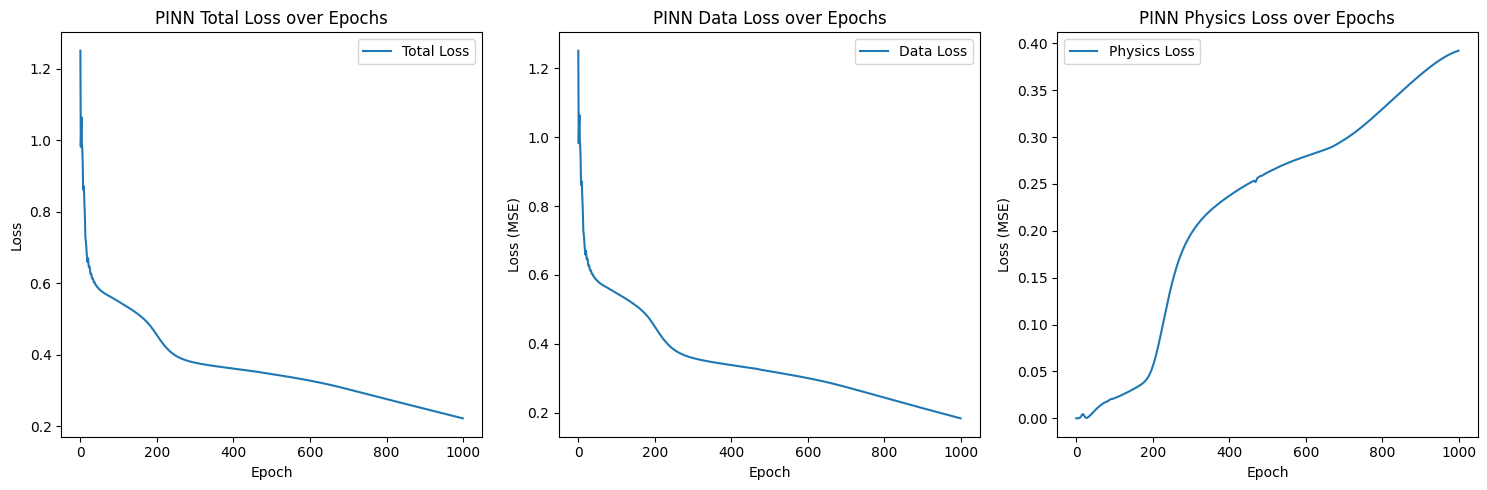

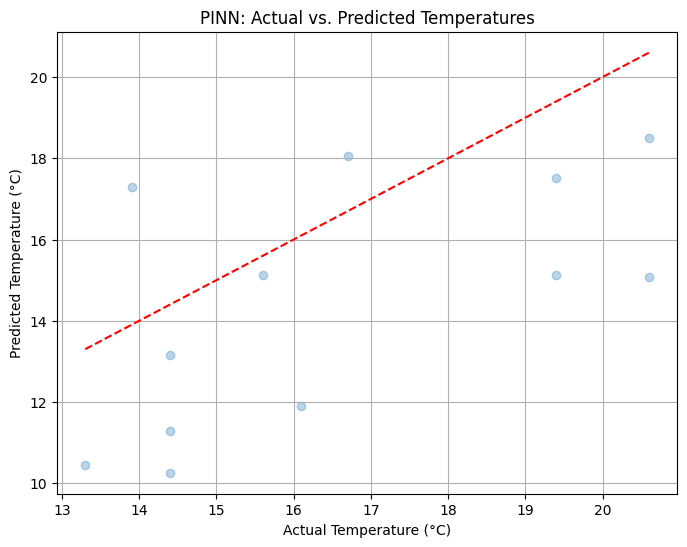

In [21]:
# Make predictions on the test set
y_pred_pinn_scaled = pinn_model(X_test_pinn_tf)

# Inverse transform predictions and actual values to original scale
y_pred_pinn = scaler_y_pinn.inverse_transform(y_pred_pinn_scaled.numpy())
y_test_pinn_unscaled = scaler_y_pinn.inverse_transform(y_test_pinn_scaled)

# Calculate MAE and MSE on unscaled data
final_mae_pinn = mean_absolute_error(y_test_pinn_unscaled, y_pred_pinn)
final_mse_pinn = mean_squared_error(y_test_pinn_unscaled, y_pred_pinn)
print(f"\nPINN Final MAE on unscaled data: {final_mae_pinn:.2f} °C")
print(f"PINN Final MSE on unscaled data: {final_mse_pinn:.2f}")

# Plot training history
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history_pinn["total_loss"], label='Total Loss')
plt.title('PINN Total Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_pinn["data_loss"], label='Data Loss')
plt.title('PINN Data Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_pinn["physics_loss"], label='Physics Loss')
plt.title('PINN Physics Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

# Visualize actual vs. predicted temperatures
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pinn_unscaled, y_pred_pinn, alpha=0.3)
plt.plot([y_test_pinn_unscaled.min(), y_test_pinn_unscaled.max()],
         [y_test_pinn_unscaled.min(), y_test_pinn_unscaled.max()], 'r--')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('PINN: Actual vs. Predicted Temperatures')
plt.grid(True)
plt.show()


In [ ]:
if california_location_id:
    california_all_station_details = get_california_station_details(california_location_id, TOKEN)
    print(f"Found {len(california_all_station_details)} California station details.")

    # Filter for GHCND stations to improve data reliability
    ghcnd_california_stations = [s for s in california_all_station_details if s.get('id') and 'GHCND' in s['id']]
    print(f"Found {len(ghcnd_california_stations)} GHCND stations in California.")

    # The original plan was to fetch temperature data here, but the user requested
    # fetching temperature per city for a specific day for the final DataFrame.
    # So, we will proceed to populate city_locations with lat/lon first.

else:
    print("Cannot fetch station details or temperature data without California Location ID.")

In [ ]:
def get_temperatures_for_major_cities(date, api_token):
    """
    Fetches the max temperature for specific major California cities on a given date.

    :param date: The date in 'YYYY-MM-DD' format.
    :param api_token: Your NOAA CDO API token.
    :return: A dictionary of city names and their max temperatures.
    """
    city_temperatures = {}
    for city_name, station_id in major_cities_stations.items():
        result = get_california_temp(station_id, date, api_token)
        city_temperatures[city_name] = result
    return city_temperatures


In [ ]:
# Example usage:
target_date_major_cities = "2023-07-15" # Using the previous example date
major_city_temps = get_temperatures_for_major_cities(target_date_major_cities, TOKEN)

print(major_city_temps["San Jose"])

### Get California Station IDs
To get a list of all weather station IDs in California, we first need to find the `locationid` for California from the NOAA API. Then, we can use this `locationid` to query the stations endpoint.

In [ ]:
city_locations = {}
for city_name, station_id_major in major_cities_stations.items():
    found = False
    for station_detail in ghcnd_california_stations:
        if station_detail['id'] == station_id_major:
            city_locations[city_name] = {
                'station_id': station_detail['id'],
                'latitude': station_detail['latitude'],
                'longitude': station_detail['longitude']
            }
            found = True
            break
    if not found:
        print(f"Location details not found for {city_name} with station ID {station_id_major}")

print("\nLatitude and Longitude for major California cities:")
for city, loc_data in city_locations.items():
    print(f"{city}: Latitude={loc_data['latitude']}, Longitude={loc_data['longitude']}")

def get_city_location(city_name, api_token):
  entry = city_locations[city_name]
  return [entry["latitude"], entry["longitude"]]

print(get_city_location("San Jose", TOKEN))

# Example usage of the new temp_for_day function
# These prints will now work correctly after modifying get_california_temp
print(f"\nTemperature for San Jose on 2023-07-15: {temp_for_day('San Jose', '2023-07-15')} °C")
print(f"Temperature for Sacramento on 2023-07-15: {temp_for_day('Sacramento', '2023-07-15')} °C")
print(f"Temperature for a NonExistentCity on 2023-07-15: {temp_for_day('NonExistentCity', '2023-07-15')}")

In [ ]:
# Define the target date for temperature data
target_date_df = "2023-07-15"

# Prepare data for the DataFrame
data_for_df = []
for city_name, loc_data in city_locations.items():
    latitude = loc_data['latitude']
    longitude = loc_data['longitude']
    temperature = temp_for_day(city_name, target_date_df)

    data_for_df.append({
        'City': city_name,
        'Latitude': latitude,
        'Longitude': longitude,
        'Date': target_date_df,
        'Temperature': temperature
    })

# Create the DataFrame
df_city_details = pd.DataFrame(data_for_df)

print(f"DataFrame with city details and temperature for {target_date_df}:")
display(df_city_details)